# A Data‑Driven Study of the Alone TV Series: Survival, Strategy, and Screens



## Why we chose this project?
Alone is s survival TV series where 10 survivalists are dropped in an extremely remote area (Arctic winter) and must fend for themselves. Its impressive to see how the winning contestants use their skills, endurance, and mental fortitude to last 100 days in such a harsh living condition.

## Data Description
It uses a collection of datasets about the TV series:

1. `survivalists.csv`
A data frame of survivalists across all 9 seasons detailing name and demographics, location and profession, result, days lasted, reasons for tapping out (detailed and categorised), page URL.

| Feature Name   | Description |
| -------- | ------- |
| `season`  | The season number   |
| `name` | Name of the survivalist     |
| `version` | The version country code (currently only US but being preppred or other versions)|
| `id` | Survivalist unique ID |
| `age` | Age of survivalist |
| `gender` | Gender |
| `city` |  City |
| `state` | State |
| `country` | Country |
|`result`| Place the survivalist finished in the season|
| `days_lasted` | The number of days lasted in the game before tapping out or winning|
| `medically_evacuated` | Logical. If the survivalist was medically evacuated from the game |
| `reason_tapped_out` | The reason the survivalist tapped out of the game. NA means they were the winner |
| `reason_category` | A simplified category of the reason for tapping out |
| `team` | The team they were associated with (only for season 4)|
| `day_linked_up` | Day the team members linked up |
| `profession` | Profession of the survivalist |
---

2. `episodes.csv`
This dataset contains details of each episode including the title, number of viewers, beginning quote and IMDb rating.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `episode_number_overall` | Episode number across seasons |
| `episode` | Episode number |
| `title` | Episode title |
| `air_date` | Date the episode originally aired |
| `viewers` | Number of viewers in the US (millions) |
| `quote` | The beginning quote |
| `author` | Author of the beginning quote |
|`imdb_rating` | IMDb rating of the episode |
| `n_ratings` | Number of ratings given for the episode |
----

3. `seasons.csv`
The season summary dataset includes location, latitude and longitude, and other season level information. It includes the date of drop off where the information exists.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `location` | Location |
| `country` | Country |
| `n_survivors` | Number of survivalists in the season. In season 4 there were 7 teams of 2 |
| `lat` | Latitude |
| `lon` | Longitude |
| `date_drop_off` | The date the survivalists were dropped off |
---

4. `loadouts.csv`
Each survivalist is allowed to take with them 10 items. This dataset includes information on each survivalist’s loadout.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `id` | Survivalist unique ID |
| `name` | Name of the survivalist |
| `item_number` | Item number |
| `item_detailed` | Detailed loadout item description |
| `item` | Loadout item. Simplified for aggregation |

## **Data Importing and Merging**

#### Mounting from drive for csv files

In [1]:
from datetime import datetime, timezone
ts = 1571595618.0
x = datetime.fromtimestamp(ts, tz=timezone.utc)
x_ts = x.timestamp()

assert ts == x_ts, f"{ts} != {x_ts}"  # This assertion succeeds


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Importing necessary libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
from sklearn.decomposition import PCA

Reading and Merging csv files into one dataframe

In [4]:
epi = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/episodes.csv')
ses = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/seasons.csv')
sur = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/survivalists.csv')
load = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/Assignment/loadouts.csv')


Merging episode level and contestant level data duplicates the rows

In [5]:
import pandas as pd

# -----------------------------
# 1. Normalize version column
# -----------------------------
for _df in [epi, ses, sur, load]:
    if 'version' not in _df.columns:
        _df['version'] = 'US'


if 'id' not in sur.columns:
    sur = sur.copy()
    sur['id'] = sur['name']  # fallback to name as unique identifier

if 'id' not in load.columns:
    load = load.copy()
    load['id'] = load['name']  # fallback for loadouts
# -------------------------------------------------
# 2. PERSON–SEASON dataframe (canonical df)
# -------------------------------------------------
df = (
    sur.merge(
        ses[['version','season','location','lat','lon','date_drop_off']],
        on=['version','season'],
        how='left'
    )
    .groupby(['version','season','id','name'], as_index=False)
    .agg({
        'age': 'first',
        'gender': 'first',
        'profession': 'first',
        'city': 'first',
        'state': 'first',
        'country': 'first',
        'days_lasted': 'max',
        'result': 'first',
        'medically_evacuated': 'first',
        'reason_category': 'first',
        'location': 'first',
        'lat': 'first',
        'lon': 'first',
        'date_drop_off': 'first',
        'team':'first'
    })
)

# Hard guarantee: no duplicate people
assert df[['version','season','id']].duplicated().sum() == 0


# -------------------------------------------------
# 3. EPISODE DATA → season-level aggregation
# -------------------------------------------------
epi_season = (
    epi.groupby(['version','season'], as_index=False)
       .agg({
           'viewers': 'mean',
           'imdb_rating': 'mean',
           'n_ratings': 'mean'
       })
)

df = df.merge(
    epi_season,
    on=['version','season'],
    how='left'
)


# -------------------------------------------------
# 4. LOADOUT DATA → collapse per person
# -------------------------------------------------
load_person = (
    load[['version','season','id','item','item_detailed']]
    .drop_duplicates()
    .groupby(['version','season','id'], as_index=False)
    .agg({'item': list, 'item_detailed' : list})
)

df = df.merge(
    load_person,
    on=['version','season','id'],
    how='left'
)


In [6]:
df_person_season = df.groupby(['version','season','name'], as_index=False).agg({
    'days_lasted': 'max',
    'age': 'first',
    'gender': 'first'
    # add more as needed
})


In [7]:
df_person_season = df.groupby(['version','season','name'], as_index=False).agg({
    'days_lasted': 'max',
    'age': 'first',
    'gender': 'first'
    # add more as needed
})
df_person_season_unique = df.drop_duplicates(subset='name', keep="first")
df_person_season_unique.head(2)


,version,season,id,name,age,gender,profession,city,state,country,...,location,lat,lon,date_drop_off,team,viewers,imdb_rating,n_ratings,item,item_detailed
0,US,1,Alan Kay,Alan Kay,40,Male,Corrections Officer,Blairsville,Georgia,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Pot, Ferro rod, Cante...","[Saw, Axe, Sleeping bag, Large 2-quart pot, Fe..."
1,US,1,Brant McGee,Brant McGee,44,Male,US Army Guard and Former US Coast Guard,Albemarle,North Carolina,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12×12 ground sheet tarp, 550 paracord – 20m, ..."


## **EDA M2 - Sarah Dsouza**


In the M2 submission , I builded up on the winner profile and looked into the size of winner and looser population which is 16, size of the winner population which is 9 and size of the looser population which is 7. Then I compared the winners and the losers such that we can ensure there is a distinct profile of winner or is it just by chance or lurking variables. The following observations were made:
- **Reasons for tapping out**: Both Family/Personal and Medical/Health category are reasons for tapping out Loosers tap out majorily due to personal or family related issues, which is mostly men. Loss of Inventory is not the major reason for tapping out, meaning the survivalist know how to maintain their inventory and use it wisely. Women tap out majorily because of medical/ health both in loosers and population as a whole.Women dont tap out majorily due to family/personal issues as compared to men.However, since we saw there is an imbalance of data with men higher in number these assumptions cannot be made entirely as women are not represented more.

- **Gear items used**: There are no items that only winners use or only loosers use. Though Saw, Axe were used by all, they are not entirely used by loosers (only 70% used them) only. Therefore, Gear items used cannot be a distinct feature to use as no such gear that 80% or more winners took that loosers took less, mostly even loosers took those gears. Gear list is not a discriminative feature for winning and loosing

- **Gender** : The casting director mostly casts for US Male as evident from their population. Out of 94, 84 are unique participants and 10 seem to be repeated. 67.8% are US Male. 79.76% are overall males that are casted with only 20.23% Female. Thus a clear distinction of winner profile cannot be made as casting director casts more males from the US. Therefore, the data is affected by a certain group. We are cannot be sure of how females would perform if casted more in number.

- **Female**: Out 17 women, 13 tap out due to medical and health issues. Medical/Health reasons are major reasons for women to leave the show. Over the ages, we see that female after 45 years dont tap out due to family/personal reasons but only medical/health reasons.Days lasted very a lot for females tapping out due to medical reaons, whereas for family/personal reasons females survival last shorter, with a spike at 45 (can be an outlier). Female above 50 are quite stronger and even though they tap out due to medical reasons they last longer in the show


- **Location**: Winners found it difficult to survive in Selenge Province in Canada and Quatsino in Canada, as they survived only 60 days. Great Slave Lake was comparitevely the easiest, as they lasted longer. Loosers found it difficult to survive in Patagonia in South America. Nunatsiavut in Canada was comparitevely easier for loosers. There are two Quatsino as 4 seasons hosted its show in Quatsino. S4 had no loosers therefore the second Quatsino does'nt have any pink color in it. A middle ground of difficulty for both winners and loosers would be Quatsino, but more analysis needs to be done about which Quatsino season it was, what factor changed, what characteristics of contestants affected this failure to stay longer in both winners and loosers

#### **Summary - on what basis can we make distinction**

All these EDA provides us with the following information. Lets see the distinction between the categories provided:


| Category   | Winner (Result == 1) | Looser  (Result == 10) |  Distinction (Yes/No) |   |
|---------------------|-------------------------------------------------------------------------------------------------------------|-----------------------------------------------|---|---|
| Country             | There were 10 winners even though there <br>were only 9 seasons because S4 had two winners.<br>Thus 70% US and 30% canadian won | All US<br>No looser for S4                    |  No |   |
| Age Range           | 24-50 <br>Mostly winners in the range 30-35                                                                                  | Range 23-55<br>Mostly 35                      | After 50 no winners. There might be a combination<br> of factors with age can play a role  |   |
| Gender              | Male                                                                                                                            |7/8 Male and 1/8 female                         | No  |   |
| Medically Evacuated | None                                                                                                                            | 2 evacuated one Male (in S6) and one female (S5) | Yes, winners not medically evacuated  |   |
|Locations            | Though most of locations are in Canada S1,S2,S3,S5,S6,S7,S8 US won;<br> where S4,S9 CAD WON                                                                                            | All loosers were from US           | No, As Quastino in S1 and S2 was won by US<br> and S4 were won by Canadian. Also the loosers<br> were from US  |   |
| Days Lasted         | Min 56 max 100 days                                                                                                             | Dont last more than 15 days                   |  Yes Winners last longer |   |
| Profession          |  Both Indoor(writer) and outdoor professionals won<br> however some outdoor professionals who work in tough environments<br> like correction officers and wilderness skills instructors did have the <br>lowest days lasted compared to others like hunting guide and even<br> freelance writers performed better than them                                              |        Both Indoor(writer) and outdoor professionals lost <br> howevers outdoor professionals like wildlife guide <br> lasted longer whereas indoor professional lasted for <br> less period                                       | No not clear  |   |
| Item (gear list)    |   all winners used Saw                                                                                                                |     Fishing gear was used by all loosers                                          | No, though there are some common tools,<br> SAW was possesed by all winners but <br> there were 70% loosers using it too   |   |



However, In M2 I focused on clustering which does'nt handle categorical variables. Here in M4 we will look into how to analyse these categorical varaibles.

#**M4 - Refinement -Sarah Dsouza**

The following is the refinement plan for this submission:
1. Deal with categorical variables through **Association Rules**
2. Refine the clustering using the numerical variables and analyze the clusters through different dimensionality reduction techniques like **PCA and UMAP** and different clustering methods like**Hierarichical and KMeans Clustering**.

## **Clustering**

Here we will look at the 2 clustering methods while also using PCA and UMAP:
- Hierarichial
- K Means


#### **Data Cleaning and Normalization**

Based on the analysis from M3, two main changes in pre processing for M4 are:
- imdb_rating also log transformed
- standardizing or normalizing the entire data before passing it to fit_transform of PCA()

In [8]:
from sklearn.preprocessing import StandardScaler
#Dropping useless columns
dfps_clean = df_person_season_unique.drop(['version','date_drop_off','item_detailed','team','id'],axis = 1)

# Replacing missing exit reasons and state with "Unknown" as values are misssing based on M3
dfps_clean["reason_category"] = dfps_clean["reason_category"].fillna("Unknown")
dfps_clean["state"] = dfps_clean["state"].fillna("Unknown")
# First, imputing missing viewers using the median within each season
dfps_clean["viewers"] = dfps_clean["viewers"].fillna(dfps_clean.groupby("name")["viewers"].transform("median"))

# Then, filling an entire season 9 missing value with the overall median
dfps_clean["viewers"] = dfps_clean["viewers"].fillna(dfps_clean["viewers"].median())
#Selecting numeric variables
num_vars = [
    "lon",
    "viewers",
    "n_ratings",
    "days_lasted",
    "age",
    "imdb_rating",
    "lat"]
# Creating log versions as the values are skewed based on M3
dfps_clean["log_viewers"] = np.log1p(dfps_clean["viewers"])
dfps_clean["log_n_ratings"] = np.log1p(dfps_clean["n_ratings"])
dfps_clean["log_imdb_rating"] = np.log1p(dfps_clean["imdb_rating"])

# Dropping raw skewed versions
df_clean = dfps_clean.drop(columns=["viewers", "n_ratings"])
# Defining the numeric variables
dfps_clean['season'] = dfps_clean['season'].astype('category')
dfps_clean['result'] = dfps_clean['result'].astype('category')
dfps_clean = dfps_clean.drop(['viewers','n_ratings','imdb_rating'], axis =1)
numeric_cols = dfps_clean.select_dtypes(include=["int64","float64"]).columns
df_num = dfps_clean[numeric_cols]


### **KMeans Clustering with PCA**

In [9]:
# Standardising the features
scaler = StandardScaler()
pca = PCA()
X_scaled = scaler.fit_transform(df_num)
df_numeric_normalized = pd.DataFrame(X_scaled, columns = df_num.columns)
transformed_data_df = pd.DataFrame(pca.fit_transform(X_scaled), columns = ['PC1', 'PC2', 'PC3','PC4', 'PC5', 'PC6','PC7'])
transformed_data_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-1.775998,-0.764183,1.312123,0.429866,0.669599,1.167722,0.077895
1,-2.436542,-0.652963,0.769326,0.607267,-0.903155,0.928003,0.073462
2,-2.523639,-0.708859,0.668723,0.256738,-0.965551,0.886907,0.068869
3,-2.452453,-0.792236,0.697846,-0.140699,-0.649369,0.903142,0.065291
4,-2.587733,-1.045891,0.472942,-1.569254,-0.403482,0.816878,0.048678
...,...,...,...,...,...,...,...
79,2.638797,-0.331171,-1.241632,-0.756823,0.801683,1.118679,-0.001005
80,2.764780,0.202973,-0.909604,2.152312,-0.039444,1.239073,0.031390
81,2.439396,-0.301747,-1.407196,-0.725265,0.335438,1.045756,-0.002579
82,2.145381,-0.307861,-1.671684,-0.941039,-0.250331,0.931576,-0.007712


In [10]:
!pip install psynlig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 130.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.8 MB/s eta 0:00:00


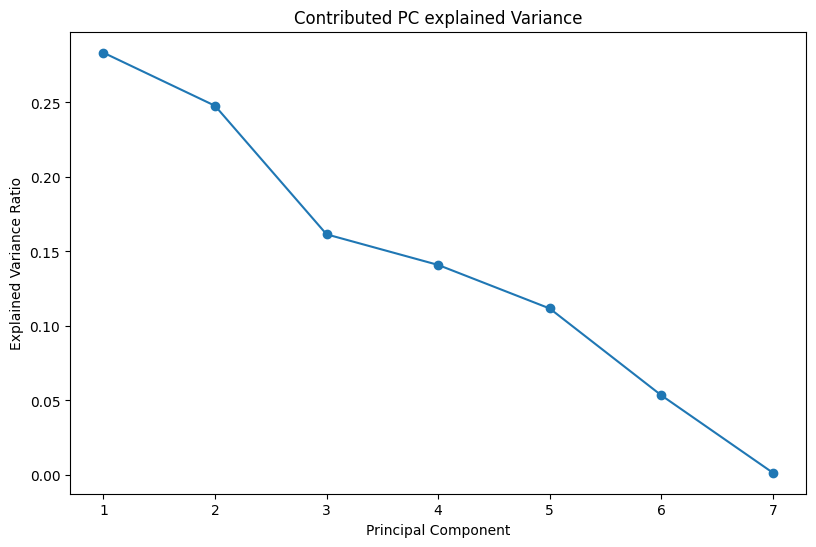

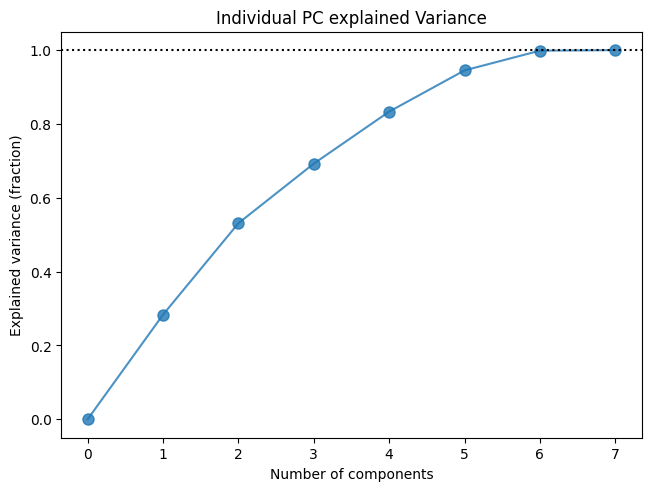

In [11]:
from sklearn.decomposition import PCA
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)
explained_variance = pca.explained_variance_ratio_
# Visualising explained variance by component to choose dimensionality

plt.figure(figsize=(9.5,6))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, len(explained_variance)+1))
plt.title('Contributed PC explained Variance')
plt.show()
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,
)

_, ax = pca_explained_variance(pca,  marker='o', markersize=8, alpha=0.8)
plt.title('Individual PC explained Variance')
plt.show()

In [12]:
# Contribution of each feature to each PC
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_num.columns)

loadings_df.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
age,0.054,0.172,0.119,0.945,-0.243,0.044,0.011
days_lasted,0.390,-0.018,0.339,0.145,0.830,0.148,0.005
lat,-0.140,0.656,-0.215,-0.098,0.072,0.629,0.305
lon,0.568,-0.393,-0.110,-0.033,-0.268,0.221,0.624
log_viewers,-0.350,-0.575,0.037,0.092,0.001,0.680,-0.272
log_n_ratings,-0.447,-0.028,0.722,-0.078,-0.062,-0.078,0.512
log_imdb_rating,0.425,0.233,0.539,-0.248,-0.413,0.250,-0.424


In [13]:
# Total variance explained by the first 3 PCs
total_variance = explained_variance[:3].sum()
print(f"{total_variance * 100:.2f}%")


69.25%


##### **Understanding the PCs**

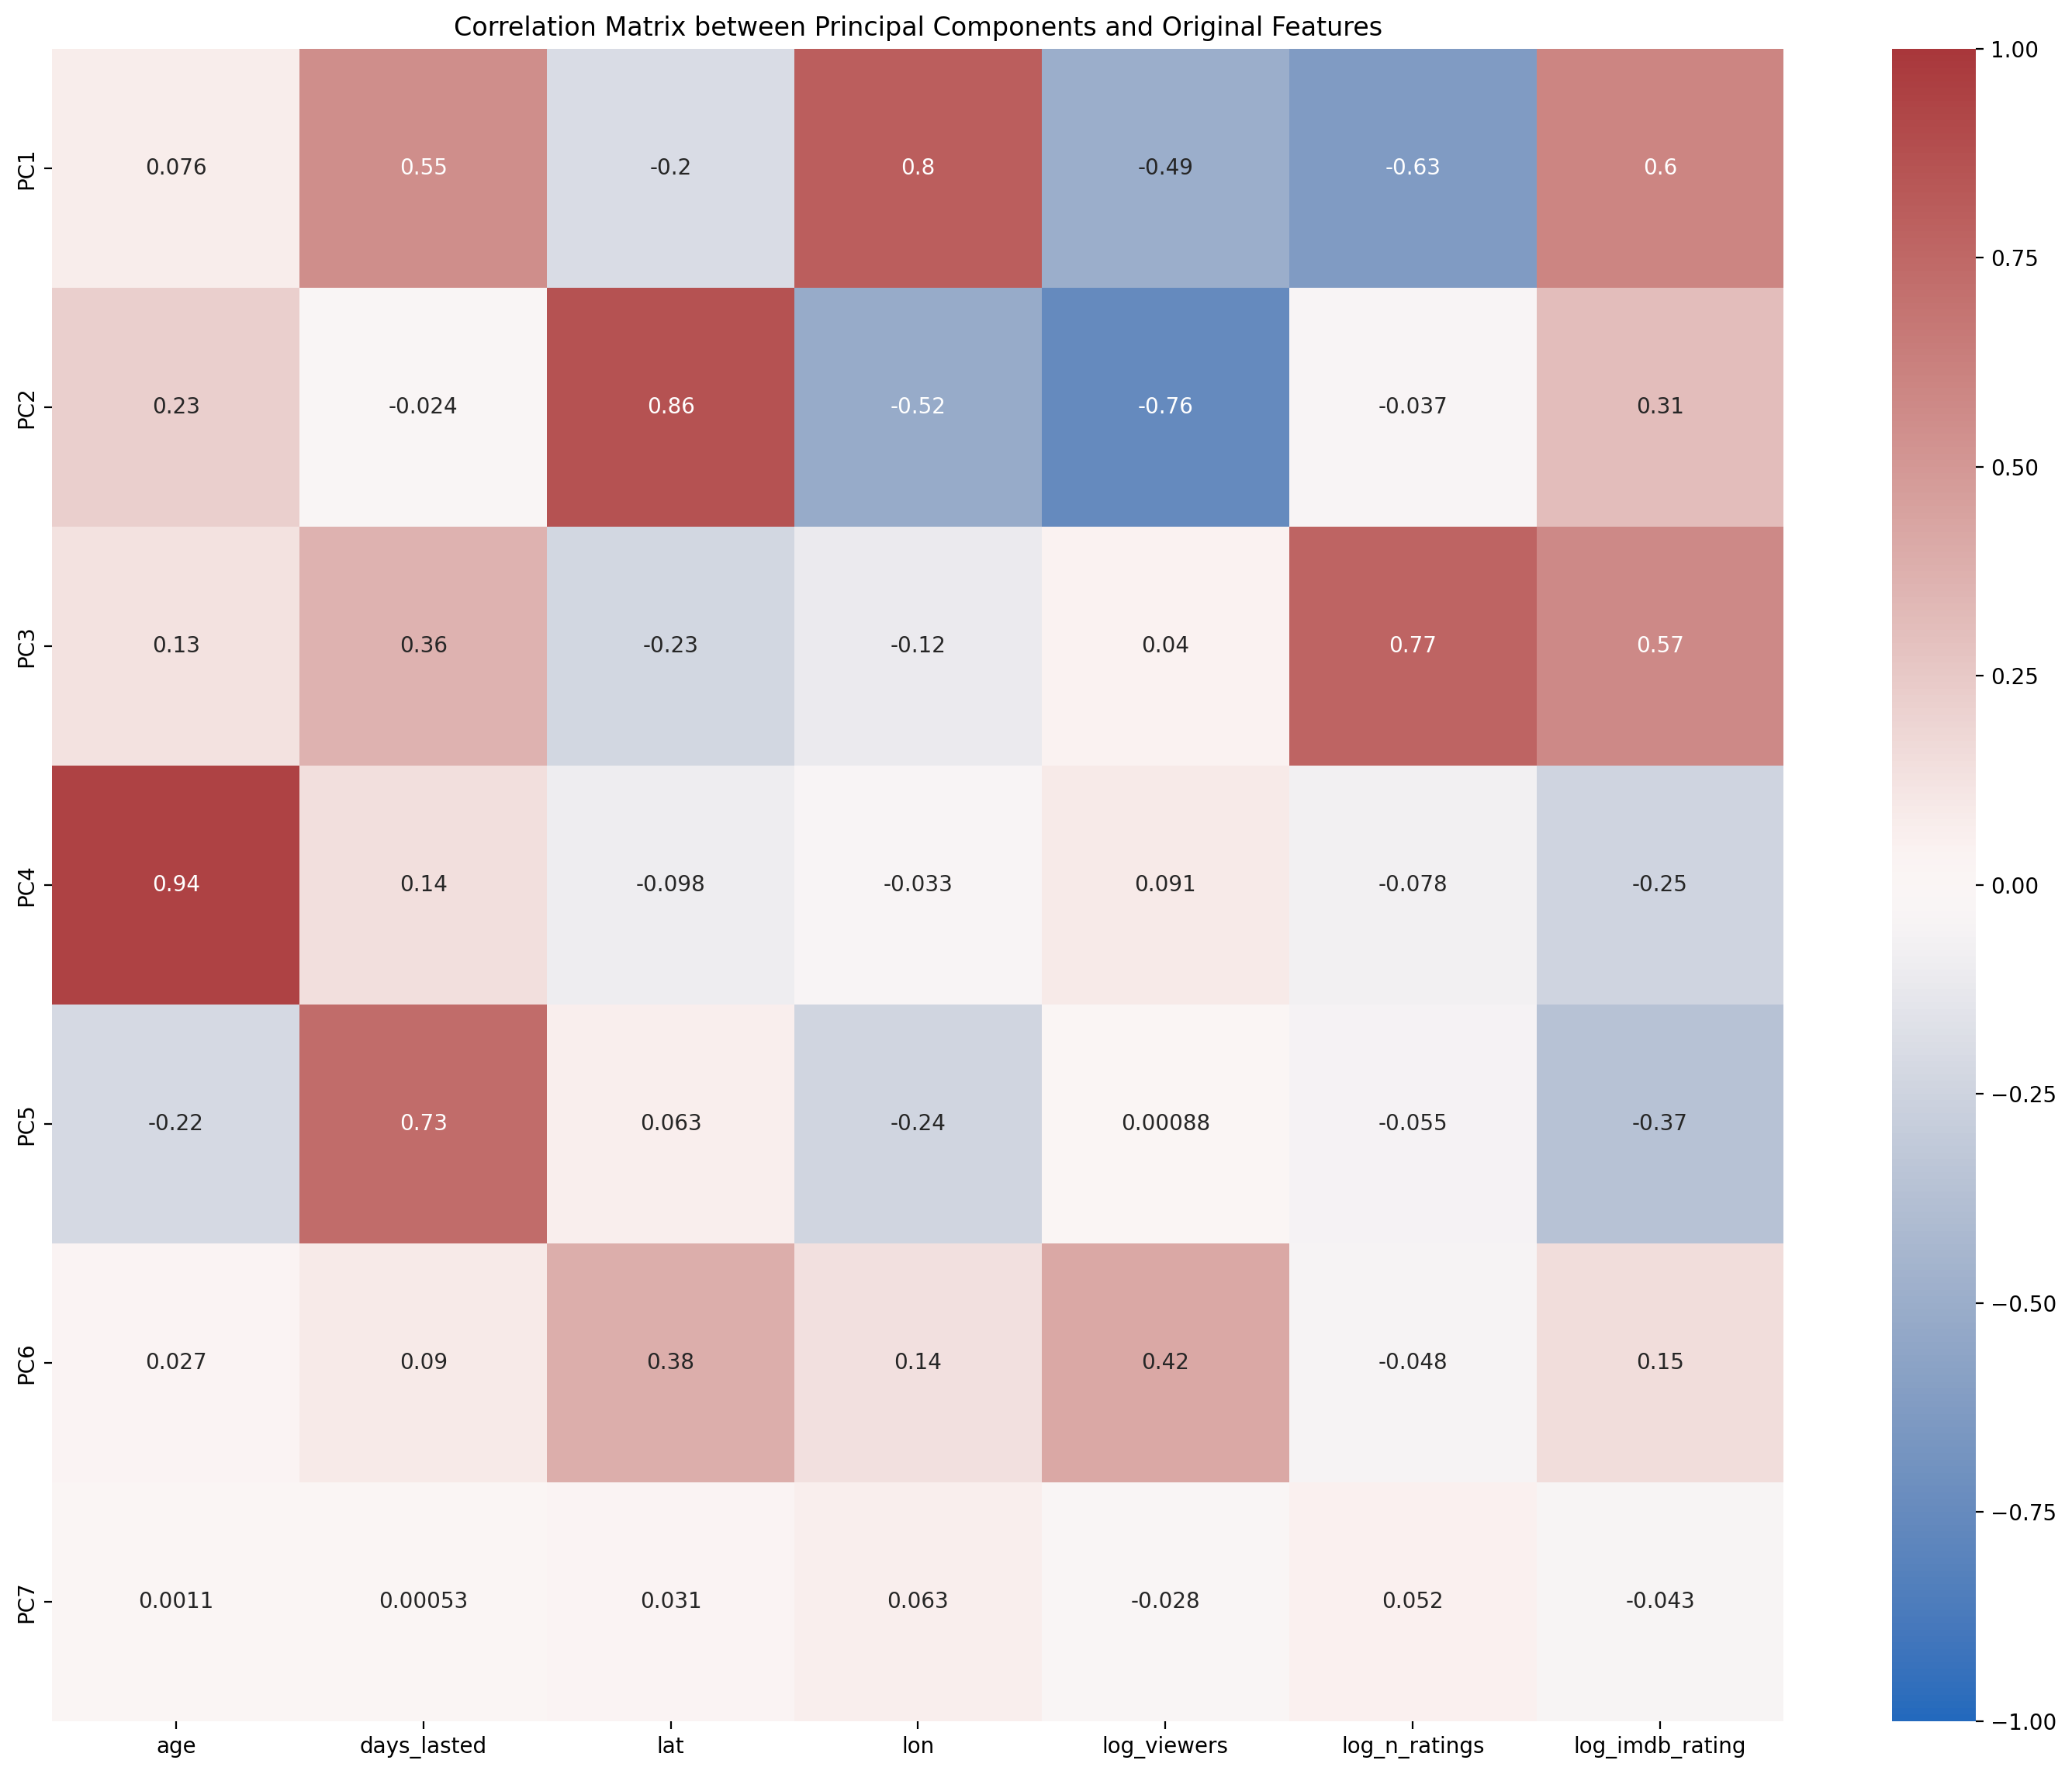

In [14]:
# Concatenate the PCs and the normalized original features
combined_df = pd.concat([transformed_data_df, df_numeric_normalized.reset_index(drop=True)], axis=1)

# Calculate the correlation matrix
correlation_pcs_original = combined_df.corr().loc[transformed_data_df.columns, df_numeric_normalized.columns]

plt.figure(figsize=(18, 14), dpi=200)
sns.heatmap(correlation_pcs_original, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix between Principal Components and Original Features')
plt.show()

([<Figure size 640x480 with 1 Axes>,
  <Figure size 640x480 with 1 Axes>,
  <Figure size 640x480 with 1 Axes>],
 [<Axes: title={'center': 'Loading coefficients for PC1'}, xlabel='Variables', ylabel='Coefficient'>,
  <Axes: title={'center': 'Loading coefficients for PC2'}, xlabel='Variables', ylabel='Coefficient'>,
  <Axes: title={'center': 'Loading coefficients for PC3'}, xlabel='Variables', ylabel='Coefficient'>])

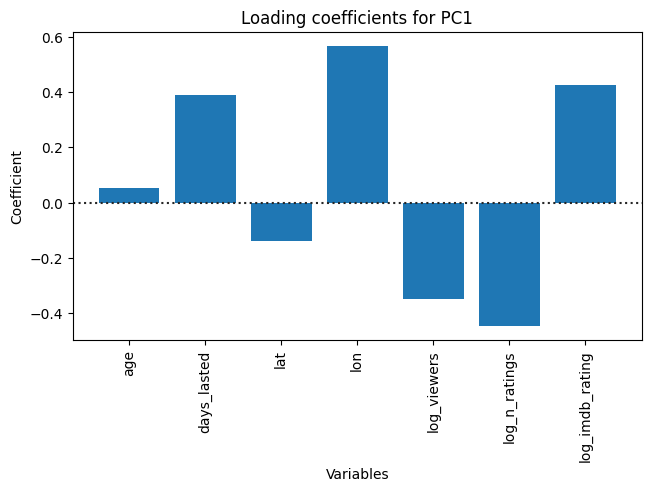

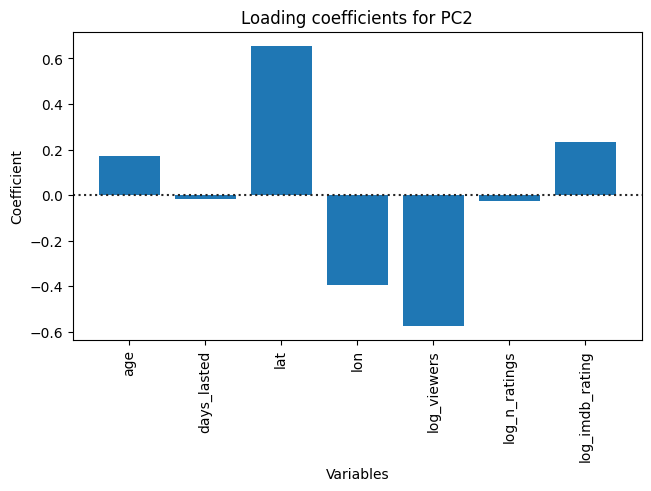

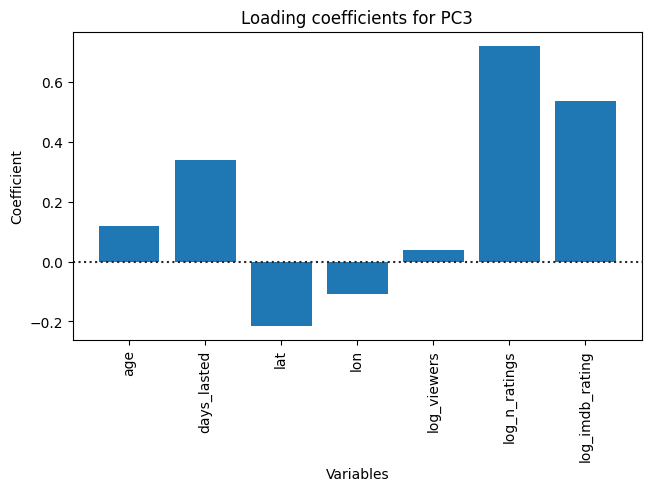

In [15]:
from psynlig import pca_1d_loadings

pca_1d_loadings(
    pca,
    df_numeric_normalized.columns,
    select_components={1, 2,3},
    plot_type="bar",
)


**Observations:**
- PC7 does'nt show much of the correlation between the numerical features
- PC4 is highly positively correlated to the age feature
- days lasted is highly positively correlated  with PC5
- Latititude is highly positively correlated with PC2
- Longitude is highly positively correlated with PC1
- Viewers is highly negatively correlated with PC2
- log_n_ratings is negatively correlated with PC1 abd positively with PC3, whereas log_imdb ratings is postively correlated with PC1 and PC3

**Inference:**

* PC1 - deals with a positive relationship with longitude and ratings; as these increase -> PC1 increases
* PC2 - deals with positive relationship with latitude but a negative relationship with viewership
* PC3 - deals with a positive relationship with number of ratings;increase in number of ratings leads to increase in PC3
* PC4 - deals with a strong positive relationship with age; increase in age leads to increase in PC4
* PC5 - deals with a positive relationship with days lasted; increase in this leads to increase in PC5
* PC6 & PC7 - low to almost no relationship with the numerical features


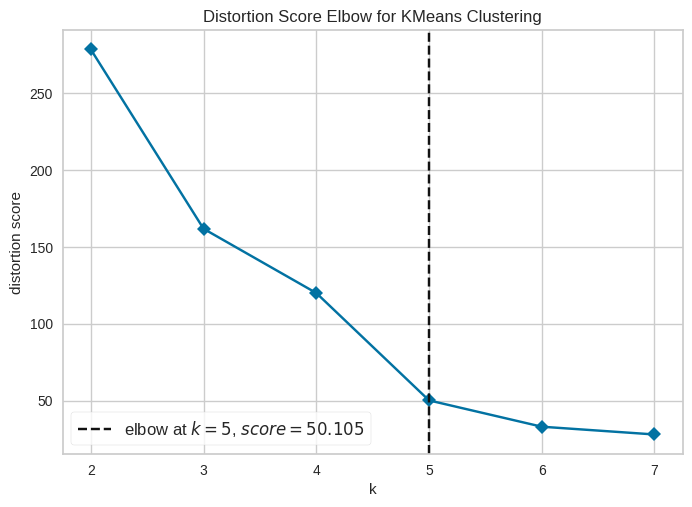

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [16]:
# Refitting PCA keeping only the first 3 components
pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_scaled)
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(2, 8),
    metric='distortion',
    timings=False)

visualizer.fit(X_reduced)
visualizer.show()

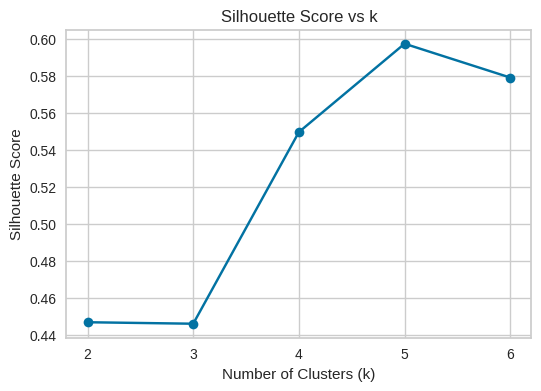

k=2: silhouette=0.447
k=3: silhouette=0.446
k=4: silhouette=0.550
k=5: silhouette=0.598
k=6: silhouette=0.579


In [17]:
from sklearn.metrics import silhouette_score
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels)
    sil_scores.append(sil)

# Plotting
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.xticks(k_values)
plt.show()

for k, score in zip(k_values, sil_scores):
    print(f"k={k}: silhouette={score:.3f}")

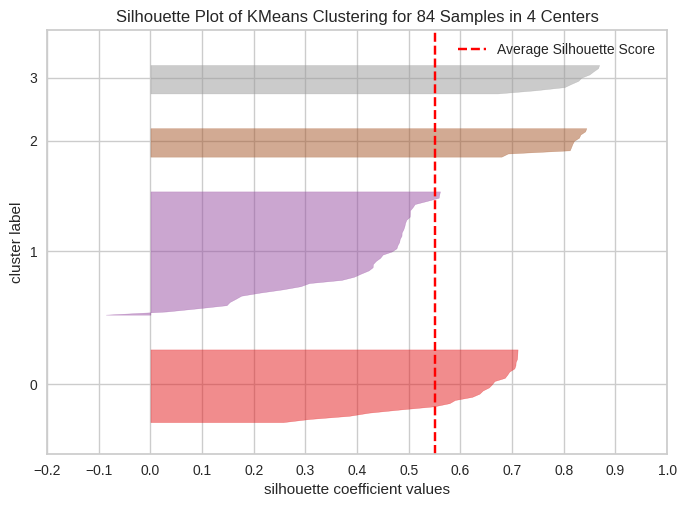

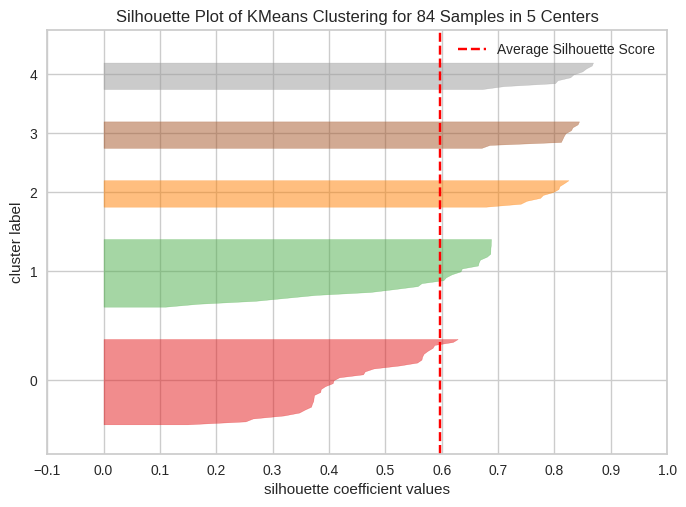

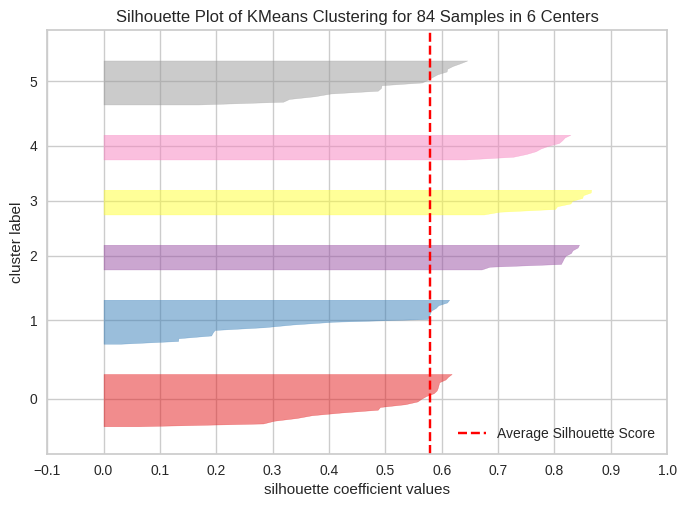

In [18]:
from yellowbrick.cluster import SilhouetteVisualizer

for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    visualizer = SilhouetteVisualizer(km)
    visualizer.fit(X_reduced)
    visualizer.show()

**Observation:** For KMeans, number of  cluster = 4, is the most appropriate due to its elbow position or low distortion and high silhouette score. Compared to other number of clusters 5 and 6, when number of  cluster = 4 the average silhoute score is 0.6. There has been an improvement since M3, due to teh addition of the pre processing steps.

In [19]:
import plotly.express as px
import plotly.graph_objects as go


# Create a 3D scatter plot
fig = px.scatter_3d( #scatter_3d scatter
    transformed_data_df,
    x="PC1",  # First principal component
    y="PC2",  # Second principal component
    z="PC3",  # Third principal component

)

fig.update_traces(
    marker=dict(
        size=3,  # Smaller marker size
        opacity=0.7  # Transparency (alpha)
    )
)


# Add an arrow for each original dimensions
scale_factor = 2  # Adjust the scale factor as needed
for i, feature in enumerate(loadings_df.columns):
    fig.add_trace(
        go.Scatter3d(
            x=[0, scale_factor * loadings_df[feature].iloc[0]],
            y=[0, scale_factor * loadings_df[feature].iloc[1]],
            z=[0, scale_factor * loadings_df[feature].iloc[2]],
            mode="lines",
            line=dict(color="red", width=5),
            showlegend=False,
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=[scale_factor * loadings_df[feature].iloc[0]],
            y=[scale_factor * loadings_df[feature].iloc[1]],
            z=[scale_factor * loadings_df[feature].iloc[2]],
            mode="text",
            showlegend=False,
            text=[f"{feature}"],  # Bold text for better readability
            textfont=dict(size=15, color="red"),  # Match text color to the line
            textposition="top center",  # Position the text more naturally
        )
    )

# ensures all axes are at the same scale
fig.update_layout(
    scene=dict(
        aspectmode="data"
    )
)

# Show the plot
fig.show()


In [20]:
n_cluster = 4
kmeans_result = KMeans(n_cluster).fit(transformed_data_df)
kmeans_result.cluster_centers_

array([[ 0.66688217,  1.34896347,  0.81529215, -0.37918911, -0.02845398,
        -0.21757555,  0.01476308],
       [-0.92360475,  0.23000891, -0.67911524,  0.37174272,  0.28815521,
        -0.26427909, -0.03590027],
       [-0.53915726, -1.88341426,  0.7999016 , -0.05415196, -0.22678658,
         0.16192791,  0.03497093],
       [ 2.24861154, -0.16071054, -1.51915864, -0.09687037, -0.3426029 ,
         0.99116277,  0.00232757]])

In [21]:
#Cluster labels
transformed_data_df['cluster_labels_k'] = kmeans_result.labels_
px.scatter_3d(transformed_data_df, x='PC1', y='PC2',z ='PC3', color='cluster_labels_k')

### **Cluster Analysis KMeans PCA**

In [22]:
dfps_with_clusters = dfps_clean.copy()

dfps_with_clusters['clusters_k_pca'] = transformed_data_df['cluster_labels_k'].values

In [23]:
cluster_members = (
    dfps_with_clusters
    .sort_values(['clusters_k_pca', 'season', 'name'])
    [['clusters_k_pca', 'season', 'name', 'days_lasted', 'log_imdb_rating']]
)

cluster_summary = (
    dfps_with_clusters
    .groupby('clusters_k_pca', as_index=False)
    .agg(
        n_contestants = ('name', 'nunique'),
        avg_days      = ('days_lasted', 'mean'),
        avg_age       = ('age', 'mean'),
        avg_imdb      = ('log_imdb_rating', 'mean'),
        avg_lat     = ('lat', 'mean'),
        avg_lon     = ('lon', 'mean'),
        avg_view = ('log_viewers', 'mean'),
        avg_rating = ('log_n_ratings', 'mean')
    )
)

cluster_members
cluster_summary


,clusters_k_pca,n_contestants,avg_days,avg_age,avg_imdb,avg_lat,avg_lon,avg_view,avg_rating
0,0,24,51.500000,38.083333,2.209264,59.794676,-115.675926,0.831571,4.182611
1,1,30,30.433333,39.600000,2.139078,50.832885,-126.808445,0.930989,4.035180
2,2,20,37.950000,35.900000,2.168603,4.862220,-97.749028,1.044620,4.380331
3,3,10,46.100000,37.600000,2.189790,59.660000,-64.273611,0.921159,3.355735


**Inferences:**

- **Cluster 0** : A small group of 10 contestants who have a high survival spirit (last longer), with an average of 36 years of age and medium level ofviewership and ratings.

- **Cluster 1**:  A large group of 54 contestants who have a lower survival spirit (days lasted are medicore), older people and lower level of viewership and medium ratings

- **Cluster 2** : A small group of 10 contestants who have a high survival spirit compared to cluster 1 and 3 but lower compared to cluster 0, with an average of 38 years of age and medium level of viewership (higher than cluster 1) and lowest ratings.

- **Cluster 3** : A small group of 10 contestants who have the lowest survival spirit, with an average of 35 years of age and highest level of viewership and high ratings

### **KMeans Clustering with UMAP**

In [24]:
import umap
import plotly.express as px
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler


# Use UMAP to reduce the dimensionality of the data
reducer = umap.UMAP(n_components=3, ) # n_neighbors=15, min_dist=0.1
umap_embeddings = reducer.fit_transform(df_numeric_normalized)

# Create a DataFrame for the UMAP embeddings
umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2","UMAP3"]) # , "UMAP3"

# Create a 3D scatter plot with hover information
fig = px.scatter_3d(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2
)

# Customize marker size
fig.update_traces(marker=dict(size=5))

# Display the plot
fig.show()



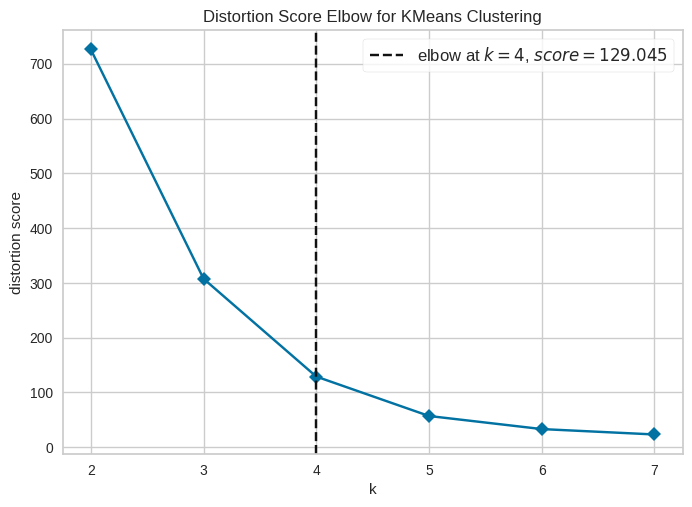

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [25]:
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(2, 8),
    metric='distortion',
    timings=False)

visualizer.fit(umap_df)
visualizer.show()

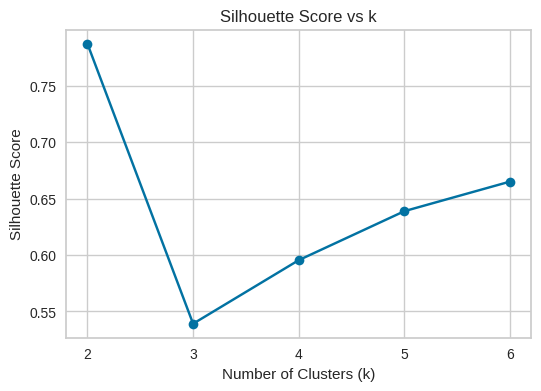

k=2: silhouette=0.787
k=3: silhouette=0.539
k=4: silhouette=0.596
k=5: silhouette=0.639
k=6: silhouette=0.665


In [26]:
from sklearn.metrics import silhouette_score
sil_scores_um = []
k_values_um = range(2, 7)

for k in k_values_um:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(umap_df.to_numpy())
    sil = silhouette_score(umap_df.to_numpy(), labels)
    sil_scores_um.append(sil)

# Plotting
plt.figure(figsize=(6,4))
plt.plot(k_values_um, sil_scores_um, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.xticks(k_values_um)
plt.show()

for k, score in zip(k_values_um, sil_scores_um):
    print(f"k={k}: silhouette={score:.3f}")

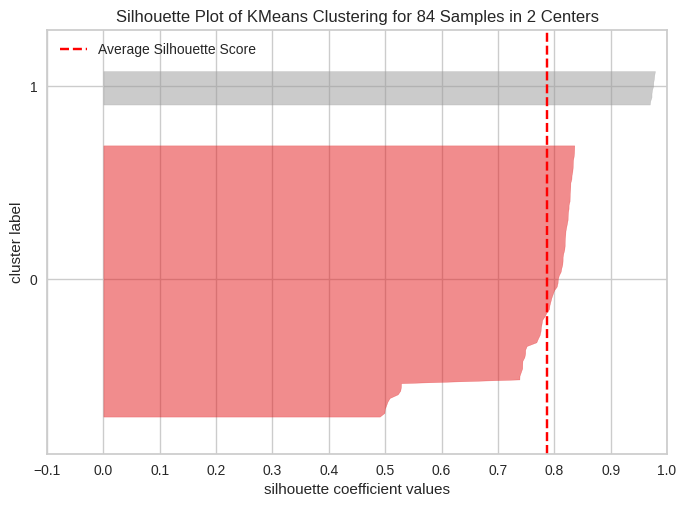

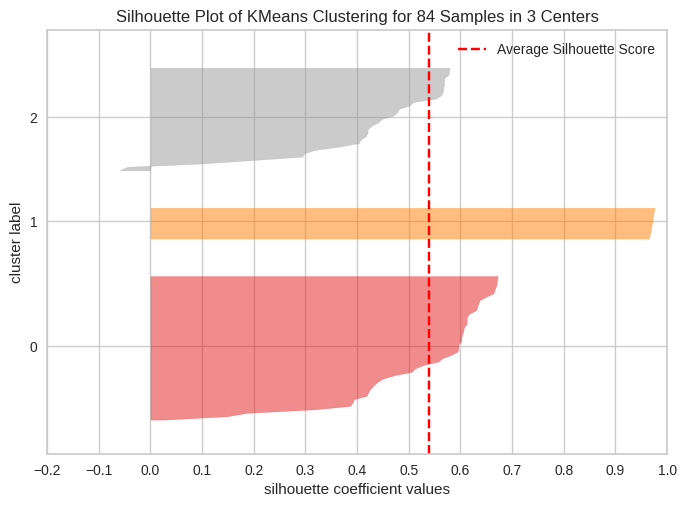

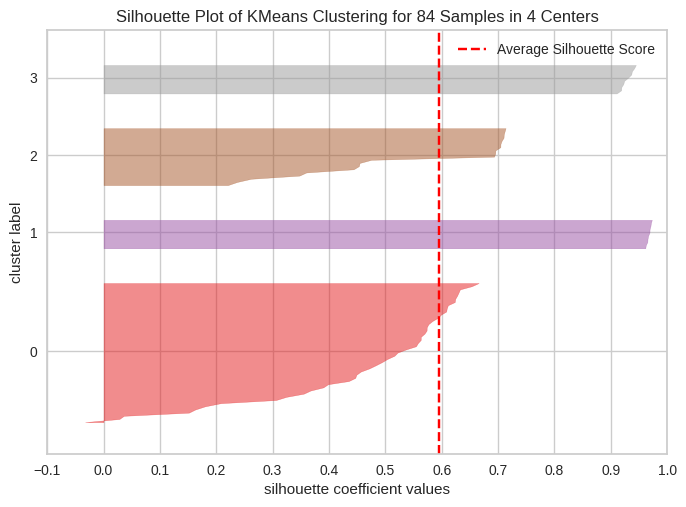

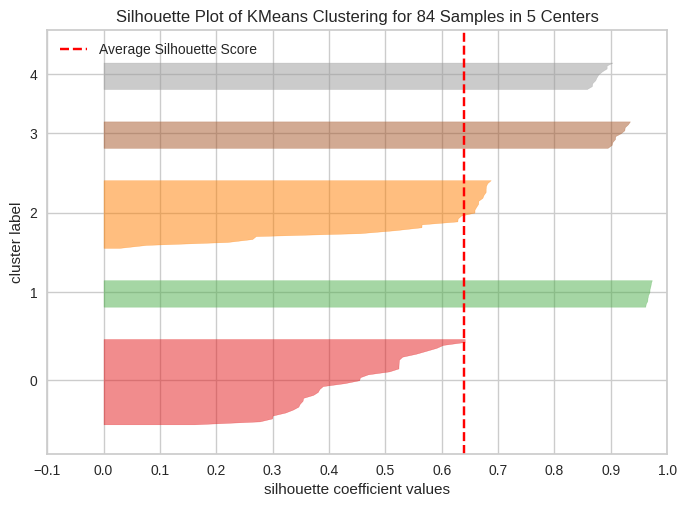

In [27]:
from yellowbrick.cluster import SilhouetteVisualizer

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    visualizer = SilhouetteVisualizer(km)
    visualizer.fit(umap_df.to_numpy())
    visualizer.show()

**Observations:** Here, we see number of clusters that is best is 4, as the silhouette score is higher than 5 cluster and at k = 4, we see an elbow, the lowest distortion compared to 2 and 3 clusters.

In [28]:
n_cluster = 4
kmeans_result_um = KMeans(n_cluster).fit(umap_df)

kmeans_result_um.cluster_centers_

array([[-0.15566647,  7.4770045 , -0.450953  ],
       [ 7.752627  , -7.0821157 ,  6.6547737 ],
       [ 0.9436956 ,  3.396655  ,  7.4339657 ],
       [ 0.35621554,  5.750688  ,  2.5411108 ]], dtype=float32)

In [29]:
#Cluster labels
umap_df['cluster_labels_um'] = kmeans_result_um.labels_
px.scatter_3d(umap_df, x='UMAP1', y='UMAP2',z ='UMAP3', color='cluster_labels_um')

### **Cluster Analysis KMeans UMAP**

In [30]:
dfps_with_clusters['cluster_k_ump'] = umap_df['cluster_labels_um'].values
cluster_members = (
    dfps_with_clusters
    .sort_values(['cluster_k_ump', 'season', 'name'])
    [['cluster_k_ump', 'season', 'name', 'days_lasted', 'log_imdb_rating']]
)

cluster_summary = (
    dfps_with_clusters
    .groupby('cluster_k_ump', as_index=False)
    .agg(
        n_contestants = ('name', 'nunique'),
        avg_days      = ('days_lasted', 'mean'),
        avg_age       = ('age', 'mean'),
        avg_imdb      = ('log_imdb_rating', 'mean'),
        avg_lat     = ('lat', 'mean'),
        avg_lon     = ('lon', 'mean'),
        avg_view = ('log_viewers', 'mean'),
        avg_rating = ('log_n_ratings', 'mean')
    )
)

cluster_members
cluster_summary


,cluster_k_ump,n_contestants,avg_days,avg_age,avg_imdb,avg_lat,avg_lon,avg_view,avg_rating
0,0,26,20.576923,34.230769,2.139807,50.724440,-127.498056,0.993518,4.237352
1,1,10,54.300000,36.700000,2.177022,-41.000000,-68.000000,1.000779,4.130355
2,2,10,46.100000,37.600000,2.189790,59.660000,-64.273611,0.921159,3.355735
3,3,38,48.157895,41.131579,2.188461,56.538625,-119.487018,0.866856,4.146578


**Inferences:**

- **Cluster 0** : A large group of 44 contestants who have the lowest survival spirit (dont last longer), who are on average 38 years of age(older) and have a medium level of viewership and lowest level ratings.

- **Cluster 1**:  A small group of 10 contestants who have a medium level survival spirit (days lasted are medicore),are on an evrage 37.6 year old and have medium level of viewership and medium level of ratings

- **Cluster 2** : A small group of 10 contestants who have the highest survival spirit, are on an average of 36 years of age (comparitevely younger) and have  the highest level of viewership and comparitevly higher rating than cluster 0 and 1.

- **Cluster 3** : A medium sized group of 20 contestants who have a medium level of survival spirit, with an average of 38 years of age but lowest of viewership and highest ratings

Clusters 0 and Cluster 3 though have a similar average age, they greatly differ in their survival spirit, imdb ratings and viewership.

### **Heirarichial Clustering with PCA**

In [31]:
hpc_df = transformed_data_df.copy()
h_df = hpc_df.drop(['cluster_labels_k'],axis = 1)
hump_df    = umap_df.copy()
umap_df = umap_df.drop('cluster_labels_um',axis = 1)

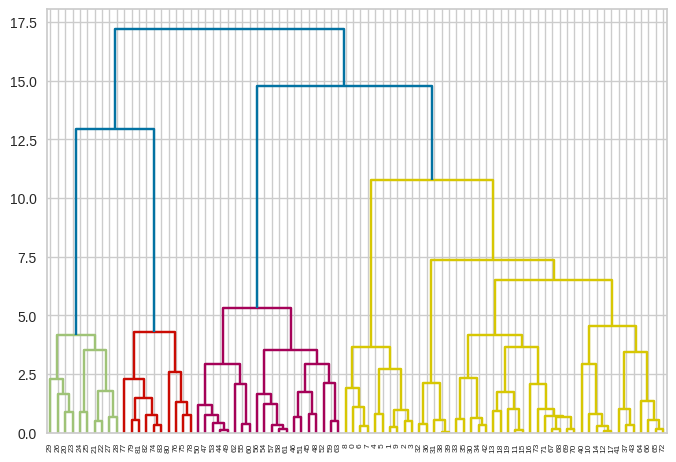

In [32]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_samples, silhouette_score


Z = linkage(h_df, 'ward') #You may try different methods and distance metrics.

_ = dendrogram(Z,)




In [33]:
# Source - https://stackoverflow.com/a/20627316
# Posted by Garrett, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-08, License - CC BY-SA 4.0
pd.options.mode.chained_assignment = None  # default='warn'
lists_w = []
for i in range(2,10):
    n_clusters = i
    h_df['cluster_label_pca_hierarichical'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
    score = silhouette_score(h_df,h_df['cluster_label_pca_hierarichical'])
    lists_w.append([i,score])

pd.DataFrame(lists_w, columns = ['n_cluster','silhouette_score'])


,n_cluster,silhouette_score
0,2,0.342877
1,3,0.332613
2,4,0.402102
3,5,0.458860
4,6,0.480050
5,7,0.479003
6,8,0.436687
7,9,0.449924


### **Cluster Analysis - Hierarichical PCA**

In [34]:
n_clusters = 6
transformed_data_df['cluster_label_pca_hierarichical'] = fcluster(Z, n_clusters, criterion='maxclust')


dfps_with_clusters['cluster_label_pca_hierarichical'] = transformed_data_df['cluster_label_pca_hierarichical'].values
cluster_members = (
    dfps_with_clusters
    .sort_values(['cluster_label_pca_hierarichical', 'season', 'name'])
    [['cluster_label_pca_hierarichical', 'season', 'name', 'days_lasted', 'log_imdb_rating']]
)

cluster_summary = (
    dfps_with_clusters
    .groupby('cluster_label_pca_hierarichical', as_index=False)
    .agg(
        n_contestants = ('name', 'nunique'),
        avg_days      = ('days_lasted', 'mean'),
        avg_age       = ('age', 'mean'),
        avg_imdb      = ('log_imdb_rating', 'mean'),
        avg_lat     = ('lat', 'mean'),
        avg_lon     = ('lon', 'mean'),
        avg_view = ('log_viewers', 'mean'),
        avg_rating = ('log_n_ratings', 'mean')
    )
)

cluster_members
cluster_summary

,cluster_label_pca_hierarichical,n_contestants,avg_days,avg_age,avg_imdb,avg_lat,avg_lon,avg_view,avg_rating
0,1,10,54.300000,36.700000,2.177022,-41.000000,-68.000000,1.000779,4.130355
1,2,10,46.100000,37.600000,2.189790,59.660000,-64.273611,0.921159,3.355735
2,3,20,47.650000,38.450000,2.216580,61.500278,-114.001111,0.817711,4.204552
3,4,10,21.600000,35.100000,2.160183,50.724440,-127.498056,1.088461,4.630306
4,5,5,4.600000,25.000000,2.116256,50.724440,-127.498056,0.921159,3.889777
5,6,29,40.448276,41.655172,2.147649,50.911415,-126.309071,0.928530,4.065452


**Inferences:**

- **Cluster 1** : A small group of 10 contestants who have the highest survival spirit (last longest), who are on average 36 years of age(older) and have a medium level of viewership and medium level ratings.

- **Cluster 2**:  A small group of 10 contestants who have a medium level survival spirit (days lasted are medicore),are on an average 37.6 year old and have mediocre level of viewership and comparitevely higher level of rating but not as compared to cluster 3.

- **Cluster 3** : A medium sized group of 20 contestants who have the higher survival spirit but not as compared to cluster 1, are on an average of 38 years of age and have the lowest level of viewership but the highest rating

- **Cluster 4** : A small sized group of 10 contestants who have a lower level of survival spirit or days lasted but not as low as cluster 5, who areon an average 35 years in age with a highest level of viewership and mediocre ratings.

- **Cluster 5** : A smallest group of 5 contestants who have the lowest survival spirit, with younger contestants and have mediocre level of viewership and lowest ratings.

- **Cluster 6** : A medium sized group of 20 contestants who have a medium level of survival spirit, with an average of 38 years of age with a mediocre level of viewership and ratings



### **Heirarichial Clustering with UMAP**

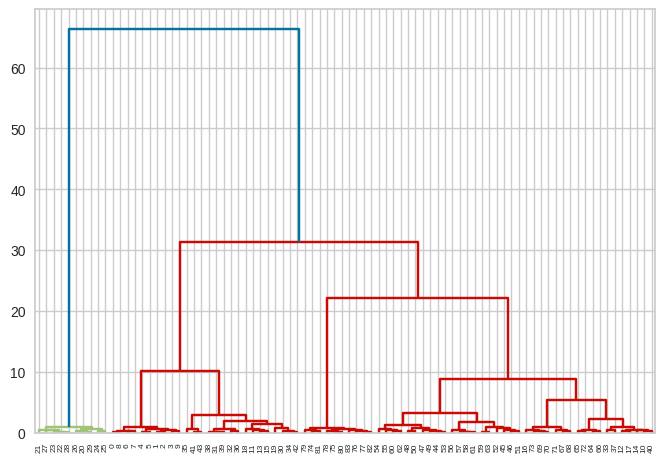

In [35]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_samples, silhouette_score


Z = linkage(hump_df, 'ward') #You may try different methods and distance metrics.

_ = dendrogram(Z,)




In [36]:
# Source - https://stackoverflow.com/a/20627316
# Posted by Garrett, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-08, License - CC BY-SA 4.0
pd.options.mode.chained_assignment = None  # default='warn'
lists_w = []
for i in range(2,10):
    n_clusters = i
    hump_df['cluster_label_umap_hierarichical'] = fcluster(Z, n_clusters, criterion='maxclust').astype(str)
    score = silhouette_score(hump_df,hump_df['cluster_label_umap_hierarichical'])
    lists_w.append([i,score])

pd.DataFrame(lists_w, columns = ['n_cluster','silhouette_score'])


,n_cluster,silhouette_score
0,2,0.763831
1,3,0.597430
2,4,0.712966
3,5,0.732511
4,6,0.710340
5,7,0.750089
6,8,0.744020
7,9,0.727684


In [37]:
n_cluster = 4
umap_df['cluster_label_umap_hierarichical'] = fcluster(Z, n_cluster, criterion='maxclust')

### **Cluster Analysis - Hierarichical UMAP**

In [38]:
dfps_with_clusters['cluster_label_umap_hierarichical'] = umap_df['cluster_label_umap_hierarichical'].values
cluster_members = (
    dfps_with_clusters
    .sort_values(['cluster_label_umap_hierarichical', 'season', 'name'])
    [['cluster_label_umap_hierarichical', 'season', 'name', 'days_lasted', 'log_imdb_rating']]
)

cluster_summary = (
    dfps_with_clusters
    .groupby('cluster_label_umap_hierarichical', as_index=False)
    .agg(
        n_contestants = ('name', 'nunique'),
        avg_days      = ('days_lasted', 'mean'),
        avg_age       = ('age', 'mean'),
        avg_imdb      = ('log_imdb_rating', 'mean'),
        avg_lat     = ('lat', 'mean'),
        avg_lon     = ('lon', 'mean'),
        avg_view = ('log_viewers', 'mean'),
        avg_rating = ('log_n_ratings', 'mean')
    )
)

cluster_members
cluster_summary

,cluster_label_umap_hierarichical,n_contestants,avg_days,avg_age,avg_imdb,avg_lat,avg_lon,avg_view,avg_rating
0,1,10,54.300000,36.700000,2.177022,-41.000000,-68.000000,1.000779,4.130355
1,2,26,20.576923,34.230769,2.139807,50.724440,-127.498056,0.993518,4.237352
2,3,10,46.100000,37.600000,2.189790,59.660000,-64.273611,0.921159,3.355735
3,4,38,48.157895,41.131579,2.188461,56.538625,-119.487018,0.866856,4.146578


**Inferences:**

- **Cluster 1** : A small group of 10 contestants who have the highest survival spirit (last longest), who are comparitevly younger on average 36 years of age, and have a medium level of viewership and medium level ratings.

- **Cluster 2**:  A medium sized group of 20 contestants who have a medium level survival spirit (days lasted are medicore comparitevely),are on an average 38 year old (older) and have lowest level of viewership and comparitevely highest level of rating.

- **Cluster 3** : A small group of 10 contestants who have the medium survival spirit as compared to cluster 1,2 and 4. They are on an average of 37 years of age and have the medium level of viewership and rating

- **Cluster 4** : A large sized group of 44 contestants with the lowest survival spirit, who are on an average 38 years in age (comparitevely oldest cluster) with a medium level of viewership and lowest ratings.





**Observation - Dimensionality Reduction:**

| Basis    | PCA | UMAP |
| -------- | ------- | -----|
|  Type of Method |  Linear  | Non Linear   |
|  Focus| Global structure    | Local and global structure |
|  Speed   | Fast    | Slower|
|  Interpretabiility   | with loadings better interpretability    | Not as interpretable|
|Cluster analysis| For heirarichical and KMeans the distinction <br> between clusters was better for example the age| The distinction of cluster was <br> not good as average age 38 present in 2 clusters.  |


**Inference - Dimensionality Reduction:** As interpretability and distinct cluster analysis is important we choose the PCA method.


**Observation - Clustering Methods:**
| Basis    | KMeans | Hierarichical |
| -------- | ------- | -----|
|  Computation|  less computationally intensive  | requires the computation and storage of an n×n  distance matrix |
|  Cluster size and shape| Specialized to clusters of<br> different sizes and shapes   | doesn’t work  as well as when the  shape of the clusters is hyper  spherical|
|  Goal  |tries to optimize variance of the clusters <br>and achieves a local optimum   | finds the best step at each cluster fusion (greedy algorithm) but might<br> lead to potentially suboptimal solution|



**Inference - Clustering Methods:** Comparing all the inferences above we can conclude that KMeans clustering had better clusters, in terms of better differentatiation in age, imdb rating and viewership. Hence we will use these cluster labels in our association rules

## **Association rules**
As most of the features in my analysis were categorical, KMean or Clustering was not useful techniques. However, as Association rules work well with categorical variables, they have been used in this M4 submission. My work can be divided into 2 question :
1. If someone took a particular Item (Gear item) how likely are they going to take another Item (Gear item)?
2. Based on the categorical features like location, reasons for tapping out, profession, gender can we associate certain features?

In [39]:
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")


####1. Gear items analysis - how likely are these gear items to be together?

In [40]:
d = df['item'].astype(str)
d = d.apply(lambda x: x.upper())
d = d.apply(lambda x: x.replace("]", ""))
d = d.apply(lambda x: x.replace("[", ""))
d = d.apply(lambda x: x.replace("'", ""))
d = d.apply(lambda x: x.replace(" ", ""))

data = list(d.apply(lambda x: x.split(',')))


In [41]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
warnings.filterwarnings("ignore", category=DeprecationWarning)
te = TransactionEncoder()
transactions = te.fit_transform(data) # or fit_transform(data)

# Create a dataframe from the data
df_encoded = pd.DataFrame(transactions, columns=te.columns_)

In [42]:

frequent_itemsets = apriori(df_encoded, min_support=0.5, use_colnames=True)
frequent_itemsets.sort_values(by="support", ascending = False)

,support,itemsets
3,0.957447,(FISHINGGEAR)
6,0.957447,(POT)
29,0.925532,"(FISHINGGEAR, POT)"
9,0.872340,(SLEEPINGBAG)
0,0.851064,(AXE)
...,...,...
82,0.500000,"(FERROROD, AXE, POT, SAW)"
89,0.500000,"(FERROROD, FISHINGGEAR, BOWANDARROWS, POT)"
93,0.500000,"(FERROROD, PARACORD, SLEEPINGBAG, FISHINGGEAR)"
103,0.500000,"(FERROROD, SLEEPINGBAG, SAW, AXE, POT)"


**Observation:** Here I have collected only frequent items that occur atleast above 50% of the time

**Inference**: Fishing gear seems to be the most frequently occured gear item, followed by pot, sleeping bag and axe.

In [43]:
rules = association_rules(frequent_itemsets,
                          num_itemsets=frequent_itemsets.shape[0],
                          metric="lift", min_threshold=1)
rules.sort_values(by=["support", "confidence","lift"], ascending=False).head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
24,(FISHINGGEAR),(POT),0.957447,0.957447,0.925532,0.966667,1.009630,1.0,0.008828,1.276596,0.224138,0.935484,0.216667,0.966667
25,(POT),(FISHINGGEAR),0.957447,0.957447,0.925532,0.966667,1.009630,1.0,0.008828,1.276596,0.224138,0.935484,0.216667,0.966667
18,(FERROROD),(SLEEPINGBAG),0.819149,0.872340,0.819149,1.000000,1.146341,1.0,0.104572,inf,0.705882,0.939024,1.000000,0.969512
3,(AXE),(FISHINGGEAR),0.851064,0.957447,0.819149,0.962500,1.005278,1.0,0.004301,1.134752,0.035250,0.827957,0.118750,0.909028
19,(SLEEPINGBAG),(FERROROD),0.872340,0.819149,0.819149,0.939024,1.146341,1.0,0.104572,2.965957,1.000000,0.939024,0.662841,0.969512
2,(FISHINGGEAR),(AXE),0.957447,0.851064,0.819149,0.855556,1.005278,1.0,0.004301,1.031097,0.123377,0.827957,0.030159,0.909028
158,"(FISHINGGEAR, SLEEPINGBAG)",(POT),0.829787,0.957447,0.797872,0.961538,1.004274,1.0,0.003395,1.106383,0.025000,0.806452,0.096154,0.897436
159,"(SLEEPINGBAG, POT)",(FISHINGGEAR),0.829787,0.957447,0.797872,0.961538,1.004274,1.0,0.003395,1.106383,0.025000,0.806452,0.096154,0.897436
160,(FISHINGGEAR),"(SLEEPINGBAG, POT)",0.957447,0.829787,0.797872,0.833333,1.004274,1.0,0.003395,1.021277,0.100000,0.806452,0.020833,0.897436
161,(POT),"(FISHINGGEAR, SLEEPINGBAG)",0.957447,0.829787,0.797872,0.833333,1.004274,1.0,0.003395,1.021277,0.100000,0.806452,0.020833,0.897436


**Inference**:
- To check which items occur together lets look at those which have high support, high confidence and high lift. We have limited our analysis to top 15 such items.
  - Pot and fishing gear are likely to occur together. Probably for cooking the fish that is caught in the pot.
  - Ferro rod and sleeping bag also are likely to occur together as ferro rod is used to produce fire and is essential for sleeping outside for heat or as a source of light
  - Sleeping bag has a high support suggesting its an essential item however its occurence should have been more, its suprising to see a lower support value
- Overall we can see items that are essential for living as a human such as catching or making food (pot, ,ferro rod and fishing gear) or sleeping (sleeping bag) are items necessary. All these are likely to occur together as these are the basic necessities for surving outdoor extremes.

####2. Combine the clusters formed from clustering methods and add the categorical varaibles to get association rules

Text(0.5, 1.0, 'Common Professions and their survival spirit')

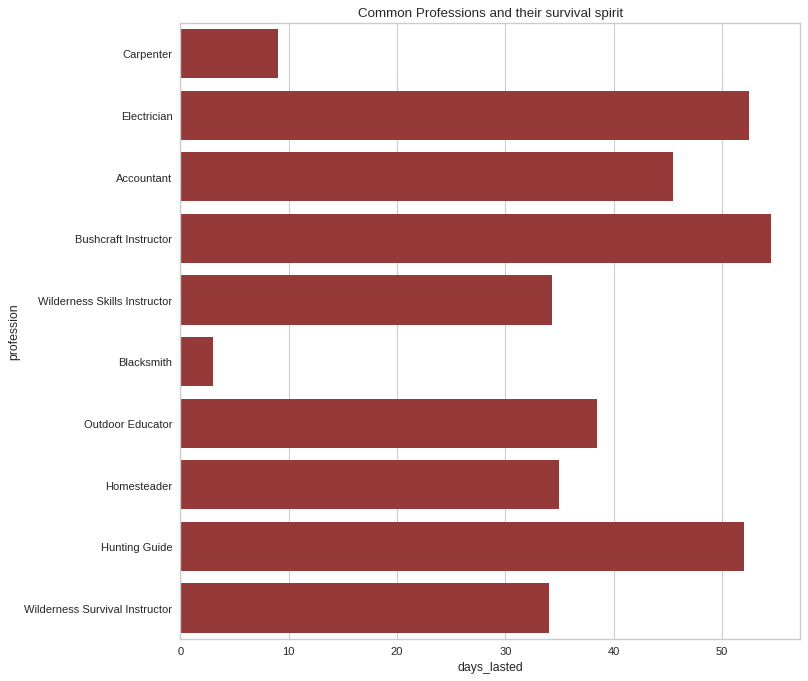

In [44]:
from matplotlib.pyplot import figure

# Source - https://stackoverflow.com/a/58536543
# Posted by jezrael, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-20, License - CC BY-SA 4.0
df1 = df[df['profession'].map(df['profession'].value_counts()) > 1]
figure(figsize=(10, 10), dpi=80)
sns.barplot(y = df1['profession'], x = df1['days_lasted'], errorbar = None, color = 'Brown')
plt.title('Common Professions and their survival spirit')


Common professions are those who occur more than once, we see that bushcraft instructor, electrician and hunting guide are the top 3 professions that lasted longer. All these profession are exposed to dangerous situations like wilderness for bushctraft instructor and hunting guide whereas electrical power for electrician. Though, the electrician lasting longer is comparetively peculiar.

In [45]:
new_df = dfps_with_clusters[['profession','clusters_k_pca', 'result','gender','country','reason_category','location']]

In [46]:
columns = new_df.columns
not_used_columns = list(set(new_df.columns.to_list()) - set(columns))
new_df = pd.get_dummies(new_df, columns=columns)
#Apriori min support
min_support = 0.1
#Max lenght of apriori n-grams
frequent_c = apriori(new_df, use_colnames=True, min_support=min_support)

##### **Let look at the association rules for different clusters formed in KMeans PCA**

#### **Cluster 0**

In [47]:
rules0 = association_rules(frequent_c, metric='lift', min_threshold=7)
rulesc0 = rules0[rules0['antecedents'] ==  frozenset({'clusters_k_pca_0'})]
rulesc0.sort_values(by=['confidence','lift','support'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


**Inferences Cluster 0**

A small group of 10 contestants who have a high survival spirit (last longer), with an average of 36 years of age and medium level of viewership and ratings are likely to occur with location Patagonia

#### **Cluster 1**

In [48]:
rules1 = association_rules(frequent_c, metric='lift', min_threshold=2)
rulesc1 = rules1[rules1['antecedents'] ==  frozenset({'clusters_k_pca_1'})]
rulesc1.sort_values(by=['confidence','lift','support'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(clusters_k_pca_1),(location_Quatsino ),0.357143,0.166667,0.166667,0.466667,2.8,1.0,0.107143,1.562500,1.0,0.466667,0.360000,0.733333
27,(clusters_k_pca_1),"(location_Quatsino , gender_Male)",0.357143,0.154762,0.154762,0.433333,2.8,1.0,0.099490,1.491597,1.0,0.433333,0.329577,0.716667
31,(clusters_k_pca_1),"(location_Quatsino , country_United States)",0.357143,0.142857,0.142857,0.400000,2.8,1.0,0.091837,1.428571,1.0,0.400000,0.300000,0.700000
71,(clusters_k_pca_1),"(location_Quatsino , gender_Male, country_Unit...",0.357143,0.130952,0.130952,0.366667,2.8,1.0,0.084184,1.372180,1.0,0.366667,0.271233,0.683333


**Inference Cluster 1:** A large group of 54 contestants who have a lower survival spirit (days lasted are medicore), older people and lower level of viewership and medium ratings are more likely to be male from the united states who tap out due to family or personal reasons and this cluster can be seen at the location at Quatsino.

#### **Cluster 2**

In [49]:
rules2 = association_rules(frequent_c, metric='lift', min_threshold=3)
rulesc2 = rules2[rules2['antecedents'] ==  frozenset({'clusters_k_pca_2'})]
rulesc2.sort_values(by=['confidence','lift','support'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(clusters_k_pca_2),(location_Patagonia),0.238095,0.119048,0.119048,0.5,4.2,1.0,0.090703,1.761905,1.0,0.5,0.432432,0.75


**Inferences Cluster 2**

 A small group of 10 contestants who have a high survival spirit compared to cluster 1 and 3 but lower compared to cluster 0, with an average of 38 years of age and medium level of viewership (higher than cluster 1) and lowest ratings, they are more likely to be male from united states and are likely to tap out due to medical or health reasons. This cluster 2 are more likely to occur in the location of Great slave lake.

#### **Cluster 3**

In [50]:
rules3 = association_rules(frequent_c, metric='lift', min_threshold=7)
rulesc3 = rules3[rules3['antecedents'] ==  frozenset({'clusters_k_pca_3'})]
rulesc3.sort_values(by=['confidence','lift','support'], ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(clusters_k_pca_3),(location_Nunatsiavut),0.119048,0.119048,0.119048,1.0,8.4,1.0,0.104875,inf,1.0,1.0,1.0,1.0


**Inferences Cluster 3**

A small group of 10 contestants who have the lowest survival spirit, with an average of 35 years of age and highest level of viewership and high ratings are more likely to occur at location Nunatsiavut.

#**Insights**

- UMAP performed slightly better as its non linear scalable and preserves the local and global structure whereas PCA is linear and good for linearly separable data. However, PCA was faster than UMAP. However for interpretability purpose we had chosen the clusters from PCA.

- Gear items that are essential for living as a human such as catching or making food (pot, ,ferro rod and fishing gear) or sleeping (sleeping bag) are items necessary. All these are likely to occur together as these are the basic necessities for surviving outdoor

- To understand our survivalists profile better a table is shown which summarizes the characteristics

| Cluster | Casting Profile/ Survivalist Profile |  |  |  |
|---|---|---|---|---|
| 0 | A small group of 10 contestants around 36 years of age, having a high <br>survival spirit (mostly winners).They give a medium level of viewership,<br>and ratings are likely to occur in the location Patagonia<br> |  |  |  |
| 1 | A large group of 54 US male contestants, around 38 years old, who have a lower survival spirit , <br>giving a lower level of viewership and medium ratings, are more likely to tap out due to family <br>or personal reasons. This cluster is more likely to be seen at the location in Quatsino. <br>|  |  |  |
| 2 | A small group of 10 US male contestants, who are also around 38 years old, with a mediocre<br>survival spirit compared to cluster 1 and 3, which account for a medium level <br>of viewership  and the lowest ratings, who are likely to tap out due to <br>medical or health reasons, and are more likely to be at the Great slave lake location <br>|  |  |  |
| 3 | A small group of 10 contestants around 35 years old who have lowest<br>survival spirit who give the highest viewership and imdb ratings. <br>These survivalist are likely to be at Nunatsiavut location.<br> |  |  |  |


#**Reference**

1. [Team Tree House](https://teamtreehouse.com/community/counting-words-in-a-string-using-a-dictionary-python-collection-challenge)
2. [Medium Data Science](https://medium.com/data-science/using-association-rules-with-categorical-data-e984f8bb8ee4)
3. [stackoverflow.com](https://stackoverflow.com/questions)
4. [Professor Elahmod](https://github.com/elhamod/BA820/)
5. [scikit](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html)
6. [Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/ml-types-of-linkages-in-clustering/)




#**Generative AI Disclosure**

ChatGPT was not used for this Phase M4. I relied on google search and on professors github files.

